# Hamiltonian sampling in Eryn

In [ ]:
import numpy as np

# plotting
import pandas as pd
import matplotlib.pyplot as plt
from chainconsumer import ChainConsumer, Chain

from eryn.ensemble import EnsembleSampler
from eryn.moves import GaussianMove
from eryn.moves.hmc_adapt import AdaptHMCMove

from eryn.moves.hmc_adapt import AdaptHMCMove
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.state import State

/Users/gfreedm1/projects/Eryn/src/eryn/moves/move.py:446: SyntaxWarning: invalid escape sequence '\l'
  :math:`\log{P} = \log{L} + \log{p}`


### Traversing Neal's funnel

A good stress test for Hamiltonian samplers is Neal's funnel. The distribution is defined as:
- $y \sim \mathcal{N}(0, \sigma_{y}^{2})$
- $x_{i} \sim \mathcal{N}(0, e^{v/2})$

First define the log posterior (here the prior density) for Neal's funnel, as well as its gradient.

In [2]:
D_TOTAL = 30  # total dims: 1 y + 29 x's
N_X = D_TOTAL - 1  # number of x components conditional on y
SIGMA_Y = 4.0  # stddev of y in Neal's funnel

LOG2PI = np.log(2 * np.pi)
SEED = 1234
np.random.seed(SEED)

In [3]:
def log_prob(theta):
    """
    theta[0] = y ~ N(0, sig_y^2)
    theta[1:] = x_i | y ~ N(0, exp(y))
    """
    y = float(theta[0])
    x = theta[1:]

    var_y = SIGMA_Y * SIGMA_Y
    logp_y = -0.5 * (y * y) / var_y - 0.5 * np.log(2.0 * np.pi * var_y)

    # guard against underflow/overflow in exp(y)
    var_x = np.exp(y)
    if not np.isfinite(var_x) or var_x == 0.0:
        # replace with a tiny positive number to avoid log(0) or inf
        var_x = max(np.finfo(float).tiny, np.sign(var_x) * np.finfo(float).tiny)

    sqterm = -0.5 * np.sum(x * x) / var_x
    normterm = -0.5 * N_X * (LOG2PI + np.log(var_x))
    logp_x = sqterm + normterm

    return logp_y + logp_x

def grad_log_prob(theta, **kwargs):
    """
    Analytic gradient of log_prob(theta) for Neal's funnel.

    d/dy log p(y) = -y / sigma_y^2

    log p(x | y) terms:
      -0.5 * sum(x_i^2) * exp(-y)
      -0.5 * N_X * y
    derivatives:
      d/dy [ -0.5 * sum(x_i^2) * exp(-y) ] = +0.5 * sum(x_i^2) * exp(-y)
      d/dy [ -0.5 * N_X * y ] = -0.5 * N_X

    d/dx_i log p(x_i | y) = -x_i / exp(y)
    """
    y = float(theta[0])
    x = theta[1:]

    grad = np.zeros_like(theta)

    var_y = SIGMA_Y * SIGMA_Y
    inv_var_x = np.exp(-y)
    # guard against overflow
    if not np.isfinite(inv_var_x):
        inv_var_x = np.finfo(float).max

    grad_y_prior = -y / var_y
    grad_y_likelihood = 0.5 * np.sum(x * x) * inv_var_x - 0.5 * N_X

    grad[0] = grad_y_prior + grad_y_likelihood
    grad[1:] = -x * inv_var_x

    return grad

# define priors
def build_prior_container():
    """
    Priors:
        y ~ Normal(0, sig_y^2)
        x_i ~ Normal(0, 1)
    """
    priors = {}

    priors[0] = uniform_dist(min=-12.0, max=5.0)
    for i in range(1, D_TOTAL):
        priors[i] = uniform_dist(min=-5.0, max=5.0)

    return ProbDistContainer(priors)

Next we can configure the HMC sampler and set our initial state and priors

In [4]:
# sampling setup
ntemps = 1
nwalkers = 16
ndim = D_TOTAL
nsteps = 500
nburnin = 50

priors = build_prior_container()
pos0 = np.zeros((nwalkers, ndim))
pos0[:, 0] = np.random.normal(0.0, 0.1, size=nwalkers)
pos0[:, 1:] = np.random.normal(loc=0.0, scale=0.1, size=(nwalkers, N_X))

Next setup the Hamiltonian Monte Carlo proposal move. For this example we use an adaptive HMC sampler, which means we will tune the integration step size during the burn-in phase. We can set an initial step_size and desired simulation trajectory length (step_size * num_steps) during initialization.

We can also choose to either use the analytic gradient defined above, or uncomment the second line to default to central finite differencing, though that will take longer to run.


In [5]:
move = AdaptHMCMove(grad_fn=None, priors=priors, step_size=1e-1, sim_length=1.0)
sampler = EnsembleSampler(nwalkers, ndim, log_prob, priors, moves=move)

There are two steps to tuning the HMC proposal scheme before beginning sampling:
- Find an initial reasonable integration step size (uses a doubling/halving algorithm).
- Adaptively adjust the step size further during a set burn-in phase.

In [6]:
# the move.tune method requires both the Model and State objects
model = sampler.get_model()
state = State(pos0)

# initial step size heuristic
move.find_initial_step_size(model, state, initial_eps=1e-1)
print(f"Initial step size: {move.step_size}")

# run a short tuning phase for burn-in
new_state = move.tune(model, state, nburnin=nburnin)

Initial step size: {'model_0': 0.8}


/Users/gfreedm1/projects/Eryn/src/eryn/ensemble.py:1276: UserWarning: All points input for the Likelihood have a log prior of -inf.
  warnings.warn(
/Users/gfreedm1/projects/Eryn/src/eryn/moves/hmc.py:259: RuntimeWarning: invalid value encountered in subtract
  delta = post_plus - post_minus


Final tuned epsilons: ['model_0: 0.22124184934385746']


After adaptation we can run the full MCMC. Feel free to adjust the number of steps taken in the chain.

In [7]:
sampler.run_mcmc(new_state, nsteps, progress=True, thin_by=1)

100%|██████████| 500/500 [00:43<00:00, 11.56it/s]


Here is a post-processing routine so we can visualize the results.

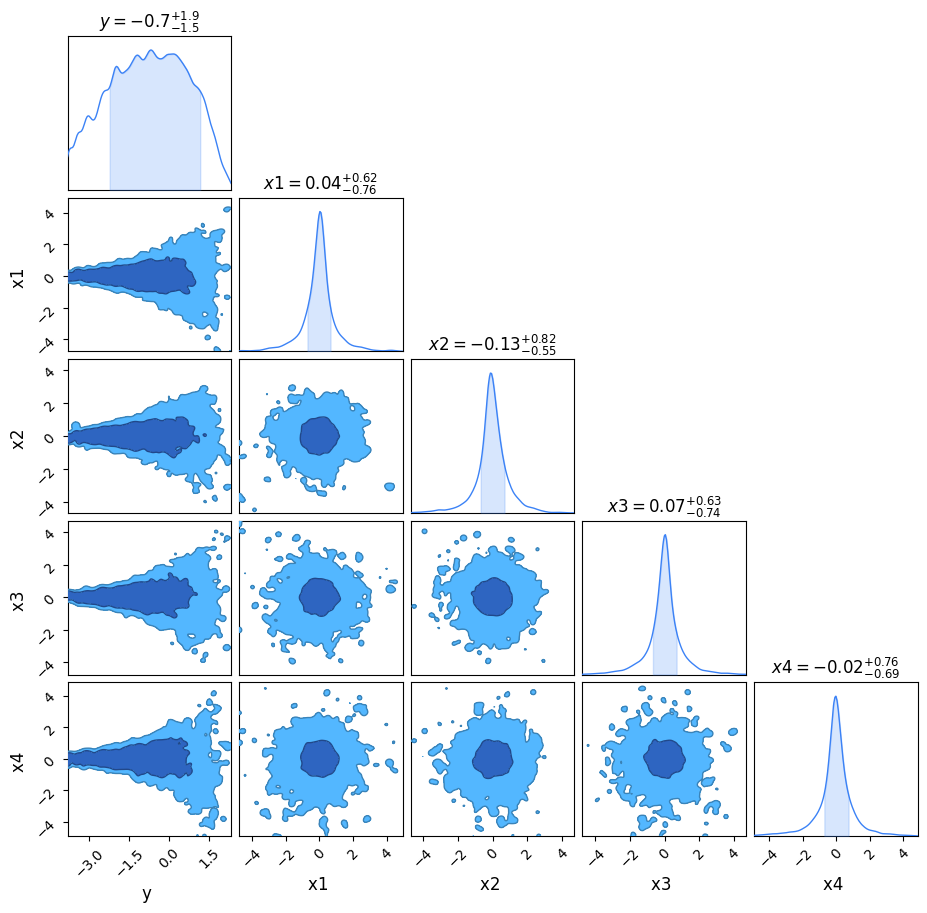

In [8]:
def process_chains(sampler, nwalkers, nsteps):
    labels = ["y"] + [f"x{i+1}" for i in range(N_X)]
    chain = sampler.get_chain()["model_0"][:, 0, :, 0, :]
    # convert to shape (nsteps, nwalkers, ndim) if necessary:
    chain = np.asarray(chain)
    if chain.shape[0] == nwalkers and chain.shape[1] == nsteps:
        # transposed shape, swap axes
        chain = np.transpose(chain, (1, 0, 2))

    # flattened samples after burn-in
    flat_samples = chain[:, :, :].reshape(-1, D_TOTAL)

    samples_df = pd.DataFrame(flat_samples, columns=labels)

    return samples_df

# no burn in for HMC since we did that during adaptation
hmc_chains = process_chains(sampler, nwalkers, nsteps)

# only plot y and the first 4 x's
subset = hmc_chains.columns[:5].tolist()
c = ChainConsumer()
c.add_chain(Chain(samples=hmc_chains[subset], name="HMC"))
c.plotter.plot(figsize=(10, 10))
plt.show()

For comparison, let's run a more traditional Gaussian proposal move MCMC routine. It should run faster than the HMC example above.

In [12]:
nwalkers_mh = 32
nsteps_mh = 5000
burnin_mh = 500

priors = build_prior_container()
pos0_mh = np.zeros((nwalkers_mh, ndim))
pos0_mh[:, 0] = np.random.normal(0.0, 0.1, size=nwalkers_mh)
pos0_mh[:, 1:] = np.random.normal(loc=0.0, scale=0.1, size=(nwalkers_mh, N_X))
cov_all = {"model_0": 2.0}
gauss = GaussianMove(cov_all)
sampler = EnsembleSampler(nwalkers_mh, ndim, log_prob, priors, moves=gauss)

sampler.run_mcmc(pos0_mh, nsteps_mh, burn=burnin_mh, progress=True)

mh_chains = process_chains(sampler, nwalkers_mh, nsteps_mh)

100%|██████████| 5000/5000 [00:02<00:00, 1867.82it/s]


Parameter y in chain MH is not constrained
Parameter x1 in chain MH is not constrained
Parameter x2 in chain MH is not constrained
Parameter x3 in chain MH is not constrained
Parameter x4 in chain MH is not constrained


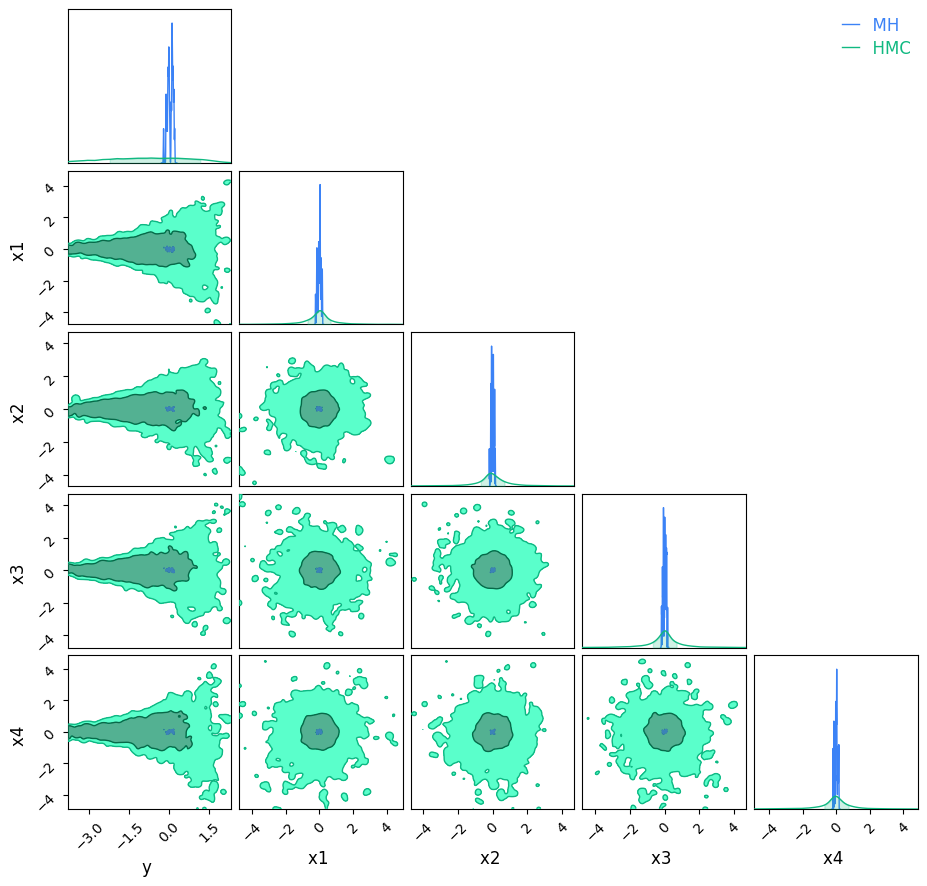

In [13]:
# Corner plot with both sets of chains plotted
subset = mh_chains.columns[:5].tolist()
c = ChainConsumer()
mh_data = Chain(samples=mh_chains[subset], name="MH")
c.add_chain(mh_data)
hmc_data = Chain(samples=hmc_chains[subset], name="HMC")
c.add_chain(hmc_data)
# c.configure(statistics="quantiles", summary=True)
c.plotter.plot(figsize=(10, 10))
plt.show()

The HMC sampler is more capable of exploring the full prior density of the funnel, even if individual samples take longer to generate. Of course, we could perform some tuning runs to optimize the Gaussian proposals, or move to other proposal schemes such as stretch moves that may work better. But for more complicated inference problems having gradient-aware samplers available to add to the proposal move scheme can be a benefit.